In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap,HeatMapWithTime
import numpy as np

In [2]:

df = pd.read_csv("data/cleaned_collision_data.csv")
ped = pd.read_csv("data/pedestrian_collisions.csv")
cyc = pd.read_csv("data/cyclist_collisions.csv")

C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\3434169742.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/cleaned_collision_data.csv")
C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\3434169742.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ped = pd.read_csv("data/pedestrian_collisions.csv")
C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\3434169742.py:3: DtypeWarning: Columns (25,26,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  cyc = pd.read_csv("data/cyclist_collisions.csv")


BOROUGH TREND ANALYSIS OVER TIME

In [3]:
ped['crash_date'] = pd.to_datetime(ped['crash_date'], errors='coerce')
cyc['crash_date'] = pd.to_datetime(cyc['crash_date'], errors='coerce')

ped['year'] = ped['crash_date'].dt.year
cyc['year'] = cyc['crash_date'].dt.year

In [17]:
ped_year_borough = ped.groupby(['borough', 'year'])[['number_of_pedestrians_injured']].sum().reset_index()
ped_year_borough_killed = ped.groupby(['borough', 'year'])[['number_of_pedestrians_killed']].sum().reset_index()

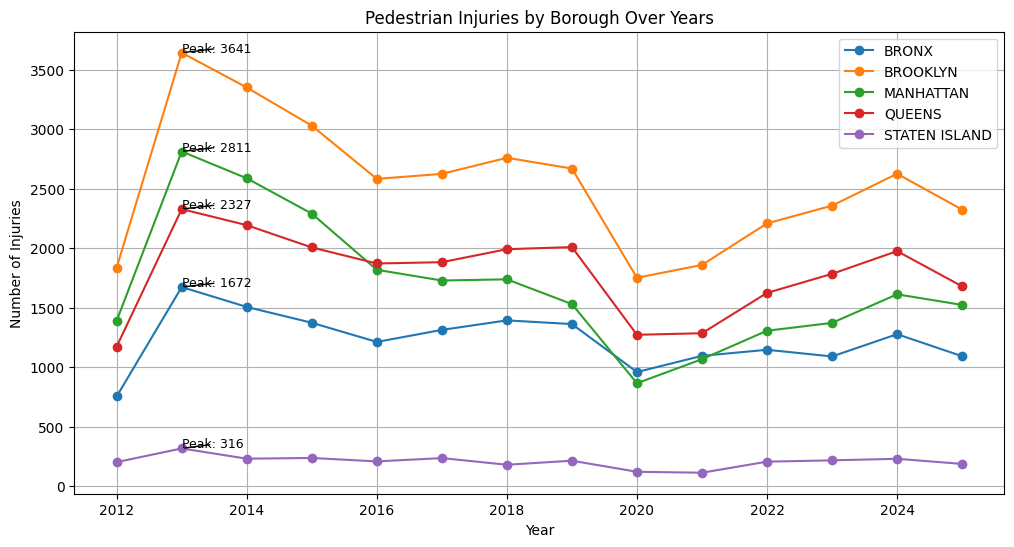

In [18]:
plt.figure(figsize=(12,6))

for b in ped_year_borough['borough'].unique():
    data = ped_year_borough[ped_year_borough['borough'] == b]
    plt.plot(data['year'], data['number_of_pedestrians_injured'], marker='o', label=b)
    peak = data.loc[data['number_of_pedestrians_injured'].idxmax()]
    plt.annotate(f"Peak: {int(peak['number_of_pedestrians_injured'])}", 
                 xy=(peak['year'], peak['number_of_pedestrians_injured']),
                 xytext=(peak['year'], peak['number_of_pedestrians_injured']+5),
                 arrowprops=dict(facecolor='black', arrowstyle='-'),
                 fontsize=9)

plt.title('Pedestrian Injuries by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.legend()
plt.grid(True)
plt.show()

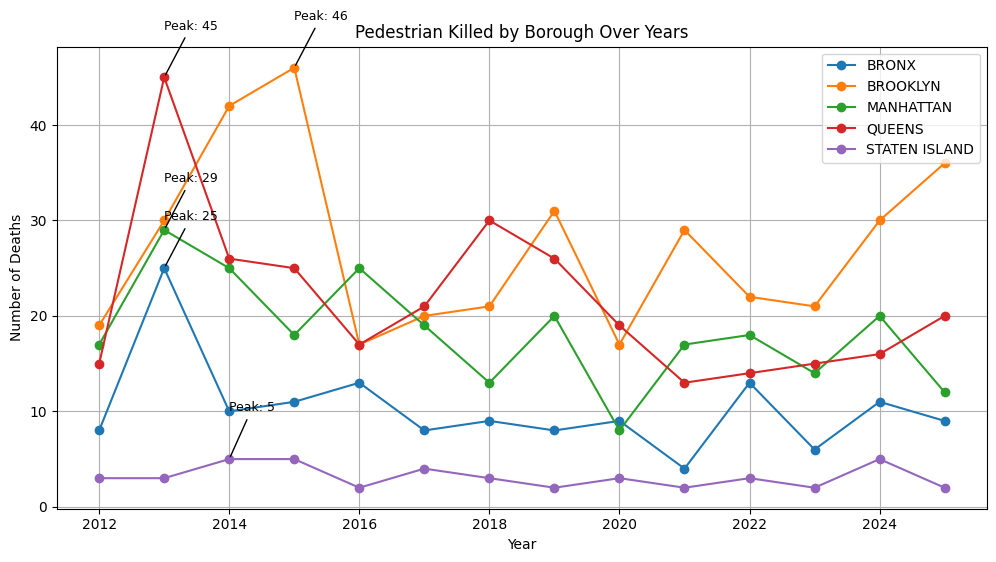

In [19]:
plt.figure(figsize=(12,6))

for b in ped_year_borough_killed['borough'].unique():
    data = ped_year_borough_killed[ped_year_borough_killed['borough'] == b]
    plt.plot(data['year'], data['number_of_pedestrians_killed'], marker='o', label=b)
    peak = data.loc[data['number_of_pedestrians_killed'].idxmax()]
    plt.annotate(f"Peak: {int(peak['number_of_pedestrians_killed'])}", 
                 xy=(peak['year'], peak['number_of_pedestrians_killed']),
                 xytext=(peak['year'], peak['number_of_pedestrians_killed']+5),
                 arrowprops=dict(facecolor='black', arrowstyle='-'),
                 fontsize=9)

plt.title('Pedestrian Killed by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
cyc_year_borough = cyc.groupby(['borough', 'year'])[['number_of_cyclist_injured']].sum().reset_index()
cyc_year_borough_killed = cyc.groupby(['borough', 'year'])[['number_of_cyclist_killed']].sum().reset_index()

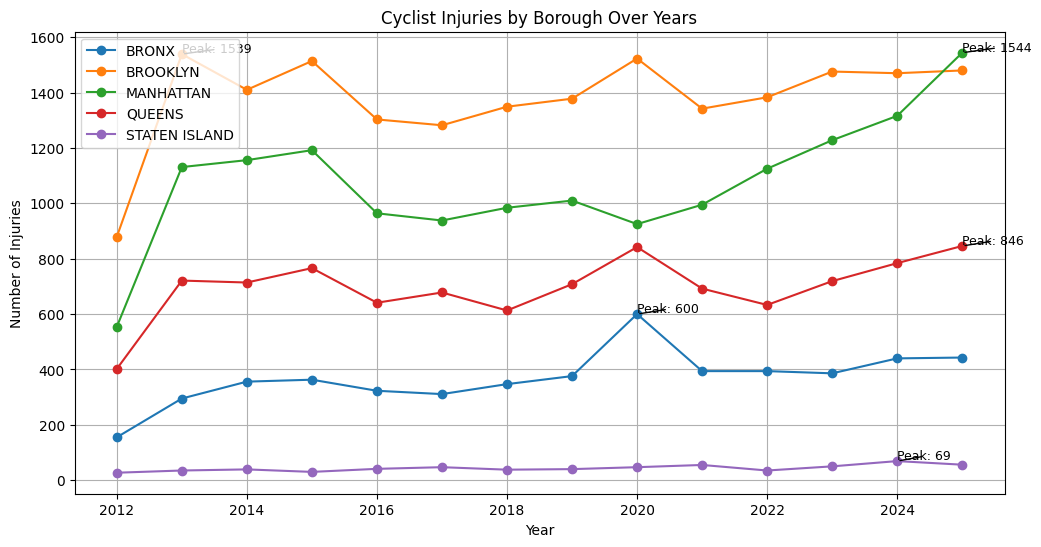

In [20]:
plt.figure(figsize=(12,6))

for b in cyc_year_borough['borough'].unique():
    data = cyc_year_borough[cyc_year_borough['borough'] == b]
    plt.plot(data['year'], data['number_of_cyclist_injured'], marker='o', label=b)
    peak = data.loc[data['number_of_cyclist_injured'].idxmax()]
    plt.annotate(f"Peak: {int(peak['number_of_cyclist_injured'])}", 
                 xy=(peak['year'], peak['number_of_cyclist_injured']),
                 xytext=(peak['year'], peak['number_of_cyclist_injured']+5),
                 arrowprops=dict(facecolor='black', arrowstyle='-'),
                 fontsize=9)

plt.title('Cyclist Injuries by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.legend()
plt.grid(True)
plt.show()


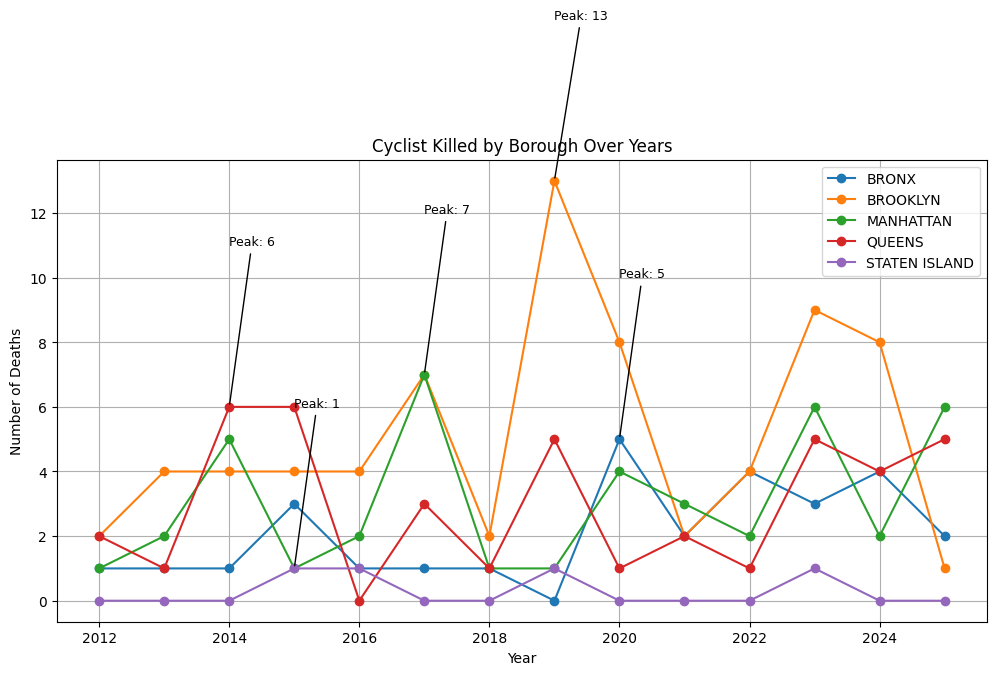

In [23]:
plt.figure(figsize=(12,6))

for b in cyc_year_borough_killed['borough'].unique():
    data = cyc_year_borough_killed[cyc_year_borough_killed['borough'] == b]
    plt.plot(data['year'], data['number_of_cyclist_killed'], marker='o', label=b)
    peak = data.loc[data['number_of_cyclist_killed'].idxmax()]
    plt.annotate(f"Peak: {int(peak['number_of_cyclist_killed'])}", 
                 xy=(peak['year'], peak['number_of_cyclist_killed']),
                 xytext=(peak['year'], peak['number_of_cyclist_killed']+5),
                 arrowprops=dict(facecolor='black', arrowstyle='-'),
                 fontsize=9)

plt.title('Cyclist Killed by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.show()


BOROUGH and TIME OF DAY ANALYSIS

In [8]:
for df_user in [ped, cyc]:
    if 'time_of_day' not in df_user.columns:
        df_user['hour'] = pd.to_datetime(df_user['crash_time'], format='%H:%M', errors='coerce').dt.hour
        def time_of_day(h):
            if 5 <= h < 12:
                return 'Morning'
            elif 12 <= h < 17:
                return 'Afternoon'
            elif 17 <= h < 21:
                return 'Evening'
            else:
                return 'Night'
        df_user['time_of_day'] = df_user['hour'].apply(time_of_day)

In [9]:
ped_borough_time = ped.groupby(['borough','time_of_day'])[['number_of_pedestrians_injured']].sum().reset_index()
cyc_borough_time = cyc.groupby(['borough','time_of_day'])[['number_of_cyclist_injured']].sum().reset_index()




In [10]:
boroughs = ped_borough_time['borough'].unique()
time_order = ['Morning','Afternoon','Evening','Night']

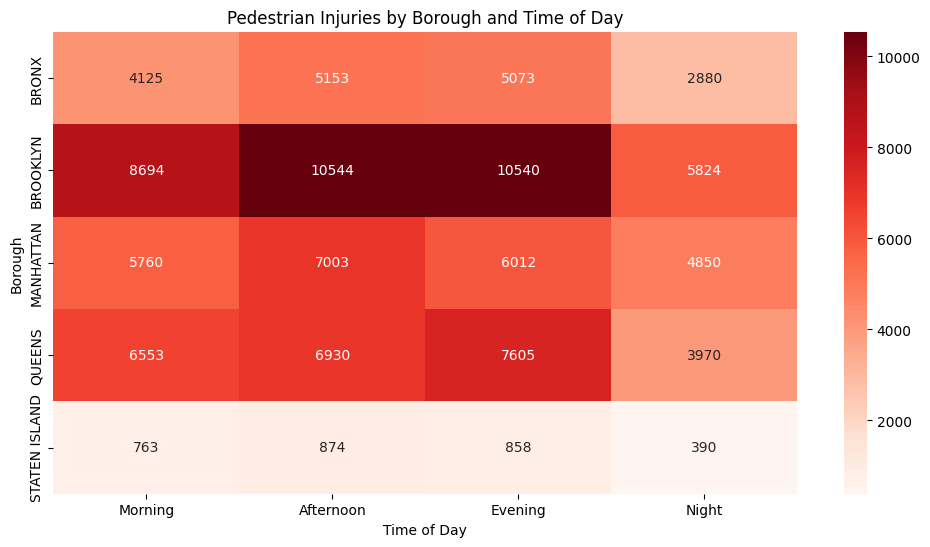

In [11]:
plt.figure(figsize=(12,6))
ped_pivot = ped_borough_time.pivot(index='borough', columns='time_of_day', values='number_of_pedestrians_injured').reindex(index=boroughs, columns=time_order)
sns.heatmap(ped_pivot, annot=True, fmt='g', cmap='Reds')
plt.title('Pedestrian Injuries by Borough and Time of Day')
plt.ylabel('Borough')
plt.xlabel('Time of Day')
plt.show()

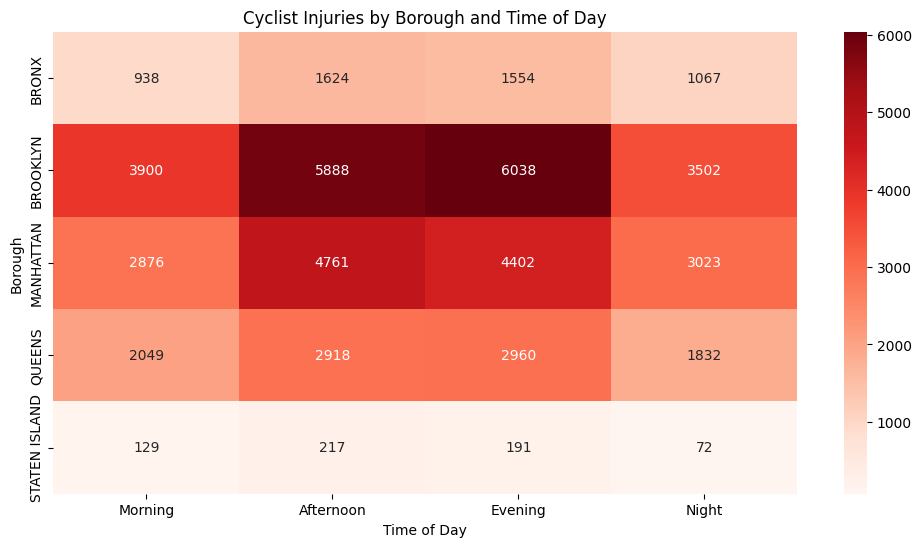

In [12]:
plt.figure(figsize=(12,6))
cyc_pivot = cyc_borough_time.pivot(index='borough', columns='time_of_day', values='number_of_cyclist_injured').reindex(index=boroughs, columns=time_order)
sns.heatmap(cyc_pivot, annot=True, fmt='g', cmap='Reds')
plt.title('Cyclist Injuries by Borough and Time of Day')
plt.ylabel('Borough')
plt.xlabel('Time of Day')
plt.show()

TOP CONTRIBUTING FACTORS ANALYSIS

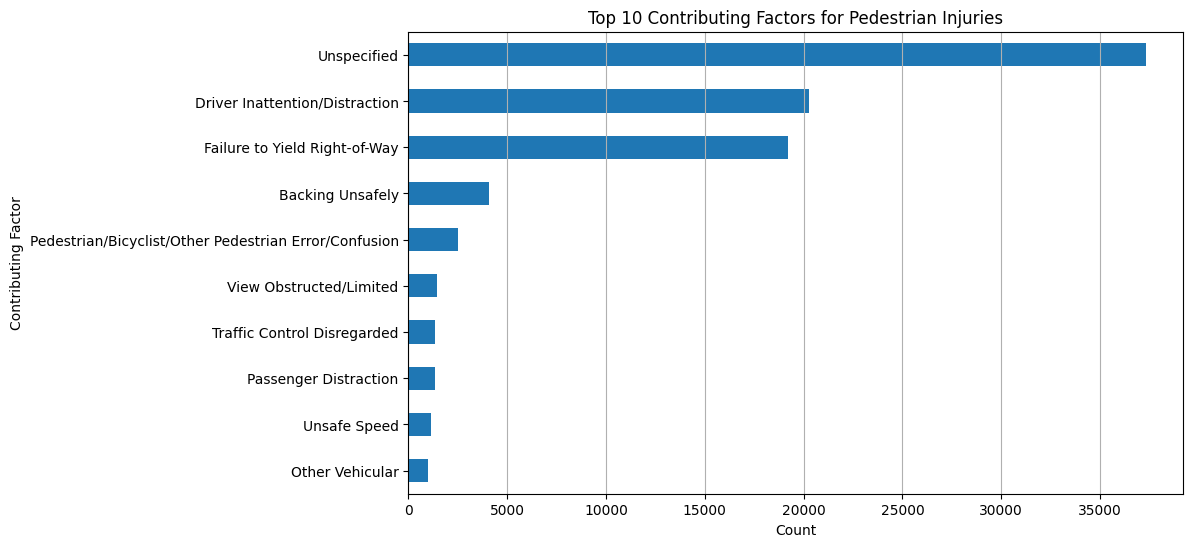

In [13]:
ped_factors = ped['contributing_factor_vehicle_1'].value_counts().head(10)

plt.figure(figsize=(10,6))
ped_factors.sort_values().plot(kind='barh')
plt.title('Top 10 Contributing Factors for Pedestrian Injuries')
plt.xlabel('Count')
plt.ylabel('Contributing Factor')
plt.grid(axis='x')
plt.show()

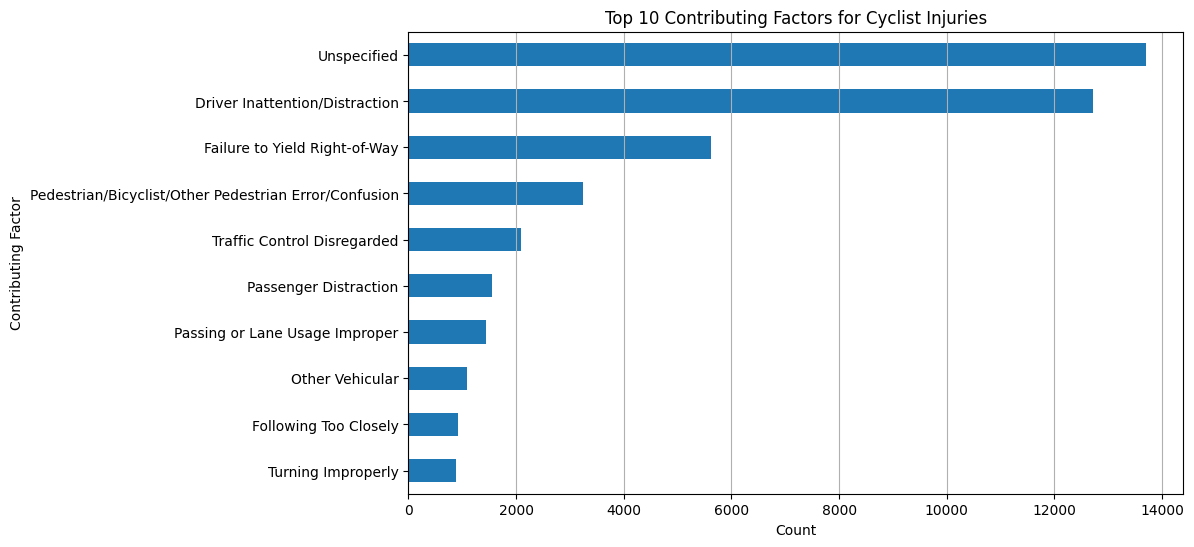

In [14]:
cyc_factors = cyc['contributing_factor_vehicle_1'].value_counts().head(10)

plt.figure(figsize=(10,6))
cyc_factors.sort_values().plot(kind='barh')
plt.title('Top 10 Contributing Factors for Cyclist Injuries')
plt.xlabel('Count')
plt.ylabel('Contributing Factor')
plt.grid(axis='x')
plt.show()

Top 10 Most Dangerous Intersections

In [48]:
df['intersection'] = df['on_street_name'].fillna('') + ' & ' + df['cross_street_name'].fillna('')
df['intersection'] = df['intersection'].str.strip().str.upper()


In [49]:
df_valid = df[df['intersection'] != '&'].copy()
for col in ['number_of_pedestrians_injured','number_of_pedestrians_killed',
            'number_of_cyclist_injured','number_of_cyclist_killed']:
    df_valid[col] = df_valid[col].fillna(0)

In [50]:
df_valid['pedestrian_risk'] = df_valid['number_of_pedestrians_injured'] + 5*df_valid['number_of_pedestrians_killed']
df_valid['cyclist_risk'] = df_valid['number_of_cyclist_injured'] + 5*df_valid['number_of_cyclist_killed']


In [ ]:
ped_top10 = df_valid.groupby('intersection')['pedestrian_risk'].sum().sort_values(ascending=False).head(10)
cyc_top10 = df_valid.groupby('intersection')['cyclist_risk'].sum().sort_values(ascending=False).head(10)


In [51]:
ped_top10

intersection
BROADWAY &              1403
3 AVENUE &               914
ATLANTIC AVENUE &        719
NORTHERN BOULEVARD &     594
FLATBUSH AVENUE &        591
NOSTRAND AVENUE &        589
5 AVENUE &               571
JAMAICA AVENUE &         534
2 AVENUE &               507
LINDEN BOULEVARD &       500
Name: pedestrian_risk, dtype: int64

In [52]:
cyc_top10

intersection
BROADWAY &            920
5 AVENUE &            499
3 AVENUE &            438
2 AVENUE &            432
BEDFORD AVENUE &      403
1 AVENUE &            348
4 AVENUE &            326
ROOSEVELT AVENUE &    301
7 AVENUE &            260
MYRTLE AVENUE &       260
Name: cyclist_risk, dtype: int64

In [53]:
df_valid['hour'] = pd.to_datetime(df_valid['crash_time'], errors='coerce').dt.hour
top10_ped_intersections = ped_top10.index.tolist()
df_top10 = df_valid[df_valid['intersection'].isin(top10_ped_intersections)]


In [54]:
hourly_peaks = (
    df_top10.groupby(['intersection','hour'])['pedestrian_risk']
    .sum()
    .reset_index()
)

In [55]:
peak_hours = hourly_peaks.loc[hourly_peaks.groupby('intersection')['pedestrian_risk'].idxmax()]
peak_hours


,intersection,hour,pedestrian_risk
15,2 AVENUE &,15,38
41,3 AVENUE &,17,77
64,5 AVENUE &,16,65
90,ATLANTIC AVENUE &,18,71
113,BROADWAY &,17,102
137,FLATBUSH AVENUE &,17,48
162,JAMAICA AVENUE &,18,49
186,LINDEN BOULEVARD &,18,51
211,NORTHERN BOULEVARD &,19,49
234,NOSTRAND AVENUE &,18,55


In [56]:
def time_of_day(h):
    if 5 <= h < 12: return "Morning"
    elif 12 <= h < 17: return "Afternoon"
    elif 17 <= h < 21: return "Evening"
    else: return "Night"

df_top10['time_of_day'] = df_top10['hour'].apply(time_of_day)

C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\1845990740.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top10['time_of_day'] = df_top10['hour'].apply(time_of_day)


In [57]:
tod_profile = (
    df_top10.groupby(['intersection','time_of_day'])['pedestrian_risk']
    .sum()
    .reset_index()
)
pivot_tod = tod_profile.pivot(index='intersection', columns='time_of_day', values='pedestrian_risk')


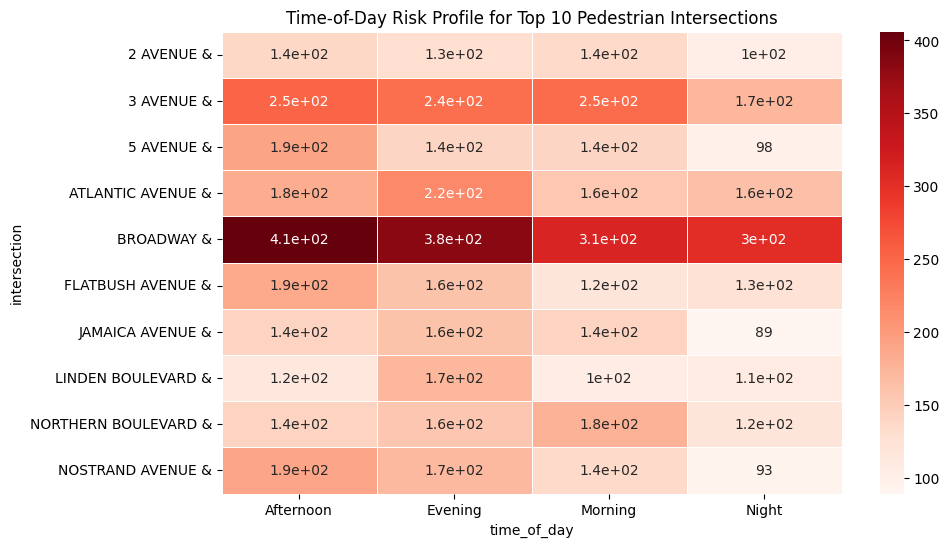

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_tod, annot=True, cmap="Reds", linewidths=0.5)
plt.title("Time-of-Day Risk Profile for Top 10 Pedestrian Intersections")
plt.show()

In [61]:
df_valid['year'] = pd.to_datetime(df_valid['crash_date'], errors='coerce').dt.year
trends = {}
for intersection in ped_top10.index:
    trends[intersection] = (
        df_valid[df_valid['intersection'] == intersection]
        .groupby('year')['pedestrian_risk']
        .sum()
        .reset_index()
    )

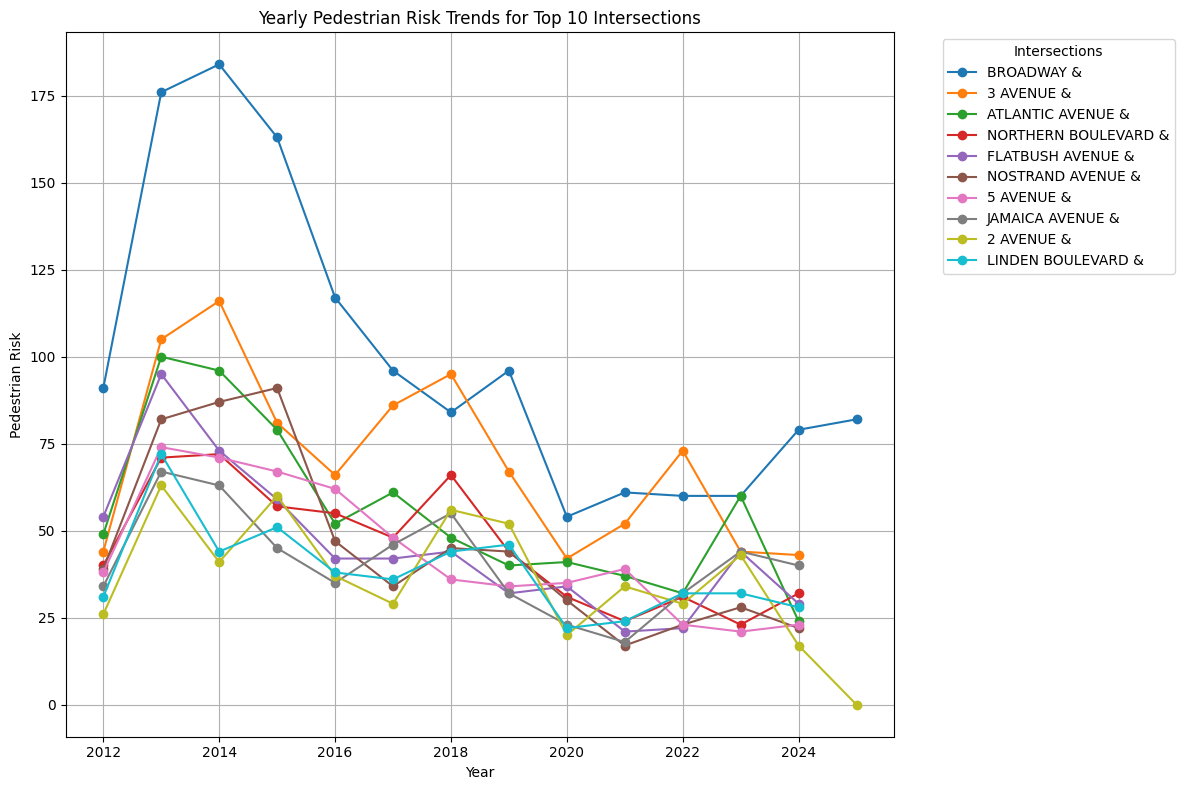

In [62]:
plt.figure(figsize=(12, 8))

for intersection, trend in trends.items():
    plt.plot(trend['year'], trend['pedestrian_risk'], marker='o', label=intersection)

plt.title("Yearly Pedestrian Risk Trends for Top 10 Intersections")
plt.xlabel("Year")
plt.ylabel("Pedestrian Risk")
plt.legend(title="Intersections", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
top10_cyc_intersections = cyc_top10.index.tolist()
df_cyc_top10 = df_valid[df_valid['intersection'].isin(top10_cyc_intersections)]

hourly_peaks_cyc = (
    df_cyc_top10.groupby(['intersection','hour'])['cyclist_risk']
    .sum()
    .reset_index()
)

In [65]:
peak_hours_cyc = hourly_peaks_cyc.loc[hourly_peaks_cyc.groupby('intersection')['cyclist_risk'].idxmax()]
print("\nPeak Hour per Intersection for Cyclists:")
print(peak_hours_cyc)


Peak Hour per Intersection for Cyclists:
           intersection  hour  cyclist_risk
19           1 AVENUE &    19            29
44           2 AVENUE &    20            36
66           3 AVENUE &    18            37
89           4 AVENUE &    17            29
112          5 AVENUE &    16            38
139          7 AVENUE &    19            24
161    BEDFORD AVENUE &    17            43
184          BROADWAY &    16            69
210     MYRTLE AVENUE &    18            23
232  ROOSEVELT AVENUE &    16            27


In [66]:
def time_of_day(h):
    if 5 <= h < 12: return "Morning"
    elif 12 <= h < 17: return "Afternoon"
    elif 17 <= h < 21: return "Evening"
    else: return "Night"

df_cyc_top10['time_of_day'] = df_cyc_top10['hour'].apply(time_of_day)

tod_profile_cyc = (
    df_cyc_top10.groupby(['intersection','time_of_day'])['cyclist_risk']
    .sum()
    .reset_index()
)
pivot_tod_cyc = tod_profile_cyc.pivot(index='intersection', columns='time_of_day', values='cyclist_risk')


C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\1399669758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cyc_top10['time_of_day'] = df_cyc_top10['hour'].apply(time_of_day)


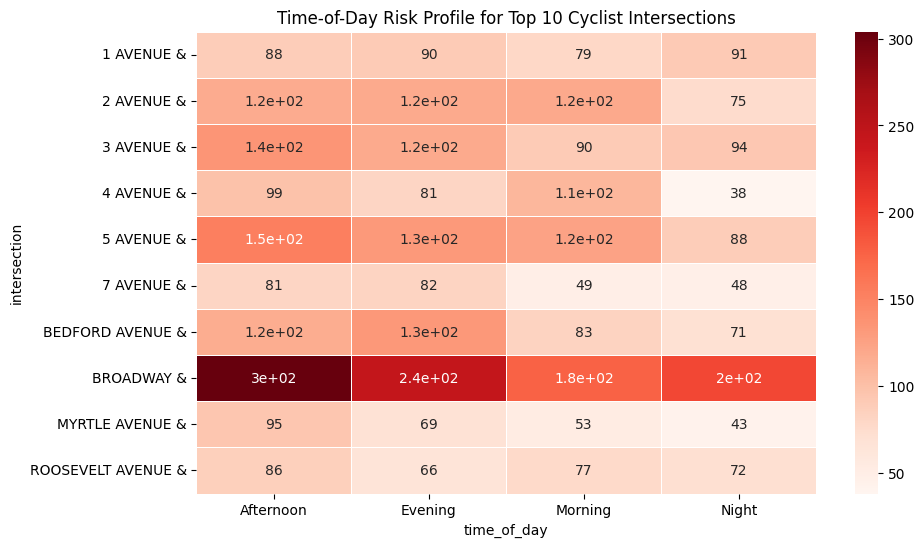

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_tod_cyc, annot=True, cmap="Reds", linewidths=0.5)
plt.title("Time-of-Day Risk Profile for Top 10 Cyclist Intersections")
plt.show()

In [70]:

trends_cyc = {}
for intersection in cyc_top10.index:
    trends_cyc[intersection] = (
        df_valid[df_valid['intersection'] == intersection]
        .groupby('year')['cyclist_risk']
        .sum()
        .reset_index()
    )

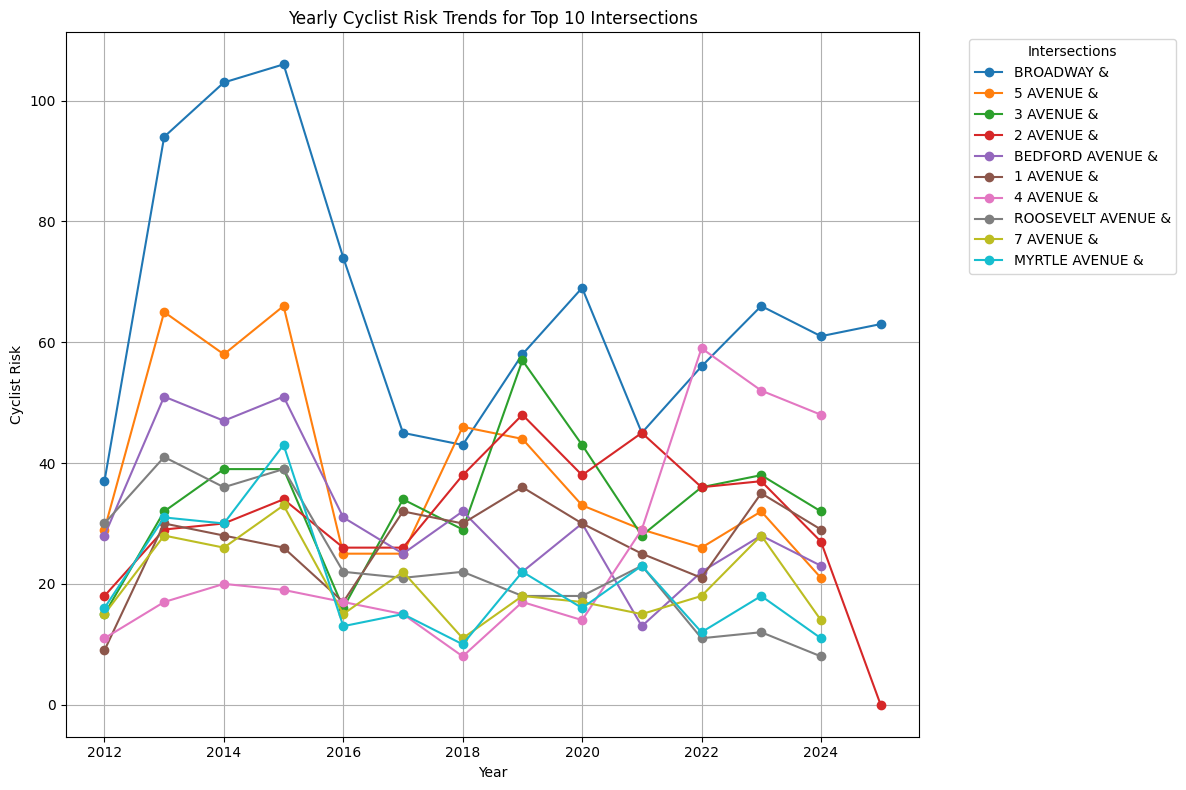

In [71]:
plt.figure(figsize=(12, 8))

for intersection, trend in trends_cyc.items():
    plt.plot(trend['year'], trend['cyclist_risk'], marker='o', label=intersection)

plt.title("Yearly Cyclist Risk Trends for Top 10 Intersections")
plt.xlabel("Year")
plt.ylabel("Cyclist Risk")
plt.legend(title="Intersections", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()